<a href="https://colab.research.google.com/github/Yaroslavwvw/neural_networks/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%962_%D0%98%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D0%B3%D0%BB%D1%83%D0%B1%D0%BE%D0%BA%D0%B8%D1%85_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D1%85_%D1%81%D0%B5%D1%82%D0%B5%D0%B9_%D0%B4%D0%BB%D1%8F_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D0%B8_%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №2. Использование глубоких нейронных сетей для решения задач регрессии и классификации



**Ссылка на код с пары:**
https://colab.research.google.com/drive/18EM8mrpURStkmbxWjZybWbWh23Si5b4A?usp=sharing


## Задание №1. Обучение модели ИНС для решения задачи регрессии



Постройте глубокую нейронную сеть для предсказания цен на недвижимость в городе Бостон, используя датасет датасет boston_housing_price

[Описание датасета](https://www.hackersrealm.net/post/boston-house-price-prediction-analysis-using-python)

#### 1.1. Загружаем исходные данные:

In [2]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)

data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

#### 1.2. Проектируем архитектуру для этой задачи

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Создаем DataFrame
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
                 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

X = pd.DataFrame(data, columns=feature_names)
y = pd.DataFrame(target, columns=['MEDV'])

# Нормализация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Архитектура модели (исправленный вариант)
model = Sequential([
    Input(shape=(X_train.shape[1],)),  # правильный входной слой
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)  # для регрессии без активации
])

# Компиляция модели
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Обучение
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=16,
    verbose=1
)

# Оценка
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest MAE: {mae:.4f}")

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 537.9903 - mae: 21.5395 - val_loss: 443.2491 - val_mae: 19.3421
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 487.5619 - mae: 20.0127 - val_loss: 329.4753 - val_mae: 16.4367
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 309.3189 - mae: 15.5988 - val_loss: 176.1229 - val_mae: 11.6130
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 164.6115 - mae: 10.8801 - val_loss: 65.7629 - val_mae: 6.4897
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 73.0522 - mae: 6.5939 - val_loss: 38.9496 - val_mae: 4.6108
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 35.7166 - mae: 4.5695 - val_loss: 31.6240 - val_mae: 3.9371
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 26.5605 - mae: 4.0308 - val_loss: 27.5937 - val_mae: 3.5690
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 23.5984 - mae: 3.7007 - val_loss: 25.4390 - val_mae: 3.4050
Epoch 9/100
26/26 ━━━━━━━━━━━━━━━

#### 1.3. Компилируем модель ИНС

Подберите нужную функцию потерь и метрику.

In [4]:
model.compile(
    optimizer='adam',
    loss='mse',  # MSE для регрессии
    metrics=['mae']  # Средняя абсолютная ошибка как метрика
)

#### 1.4. Обучаем модель ИНС

In [5]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - loss: 5.3772 - mae: 1.7673 - val_loss: 7.4644 - val_mae: 2.0273
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.8392 - mae: 1.7256 - val_loss: 7.8097 - val_mae: 2.0362
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.6882 - mae: 1.7962 - val_loss: 7.8501 - val_mae: 2.0494
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.0302 - mae: 1.8440 - val_loss: 8.2464 - val_mae: 2.0831
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.8881 - mae: 1.9580 - val_loss: 7.7368 - val_mae: 2.0175
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.9403 - mae: 1.8207 - val_loss: 7.8457 - val_mae: 2.0574
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.5405 - mae: 1.7603 - val_loss: 7.6901 - val_mae: 2.0339
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.6424 - mae: 1.7139 - val_loss: 7.4463 - val_mae: 2.0088
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.7

#### 1.6. Делаем предсказания на тестовых данных

In [6]:
y_pred = model.predict(X_test)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


#### 1.7. Вычисляем метрику качества на тестовых данных

In [7]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test MSE: {test_loss:.2f}")
print(f"Test MAE: {test_mae:.2f}")

Test MSE: 10.22
Test MAE: 2.13


#### 1.8. Строим график обучения

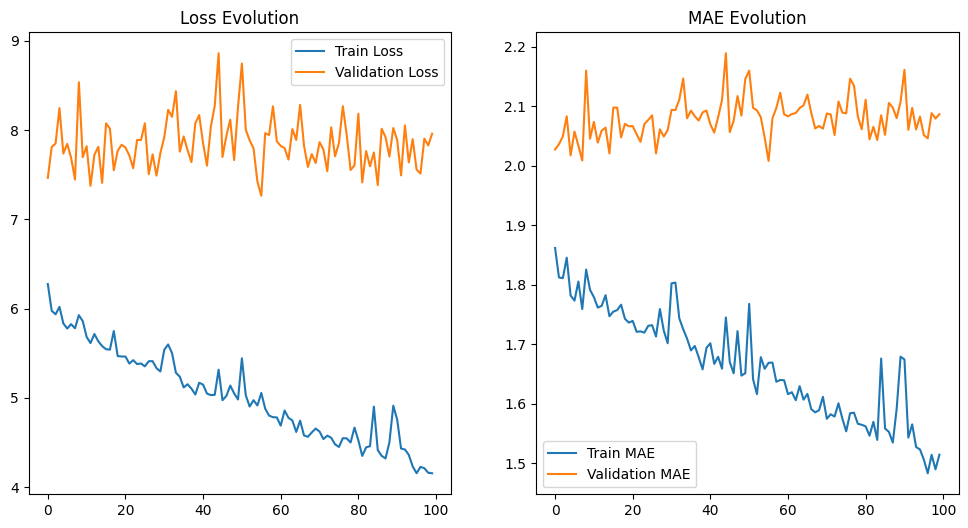

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Evolution')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('MAE Evolution')
plt.legend()
plt.show()

#### 1.9. Построение графического интерфейса в Gradio Проверка обученной модели пользовательскими данными

In [9]:
!pip install gradio

In [10]:
import gradio as gr

def predict_price(crim, zn, indus, chas, nox, rm, age, dis, rad, tax, ptratio, b, lstat):
    input_data = np.array([[crim, zn, indus, chas, nox, rm, age, dis, rad, tax, ptratio, b, lstat]])
    scaled_input = scaler.transform(input_data)
    prediction = model.predict(scaled_input)[0][0]
    return f"Predicted price: ${prediction*1000:.2f}"

inputs = [gr.Number(label=name) for name in feature_names]
gr.Interface(fn=predict_price, inputs=inputs, outputs="text").launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3508a6c09aeff30016.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


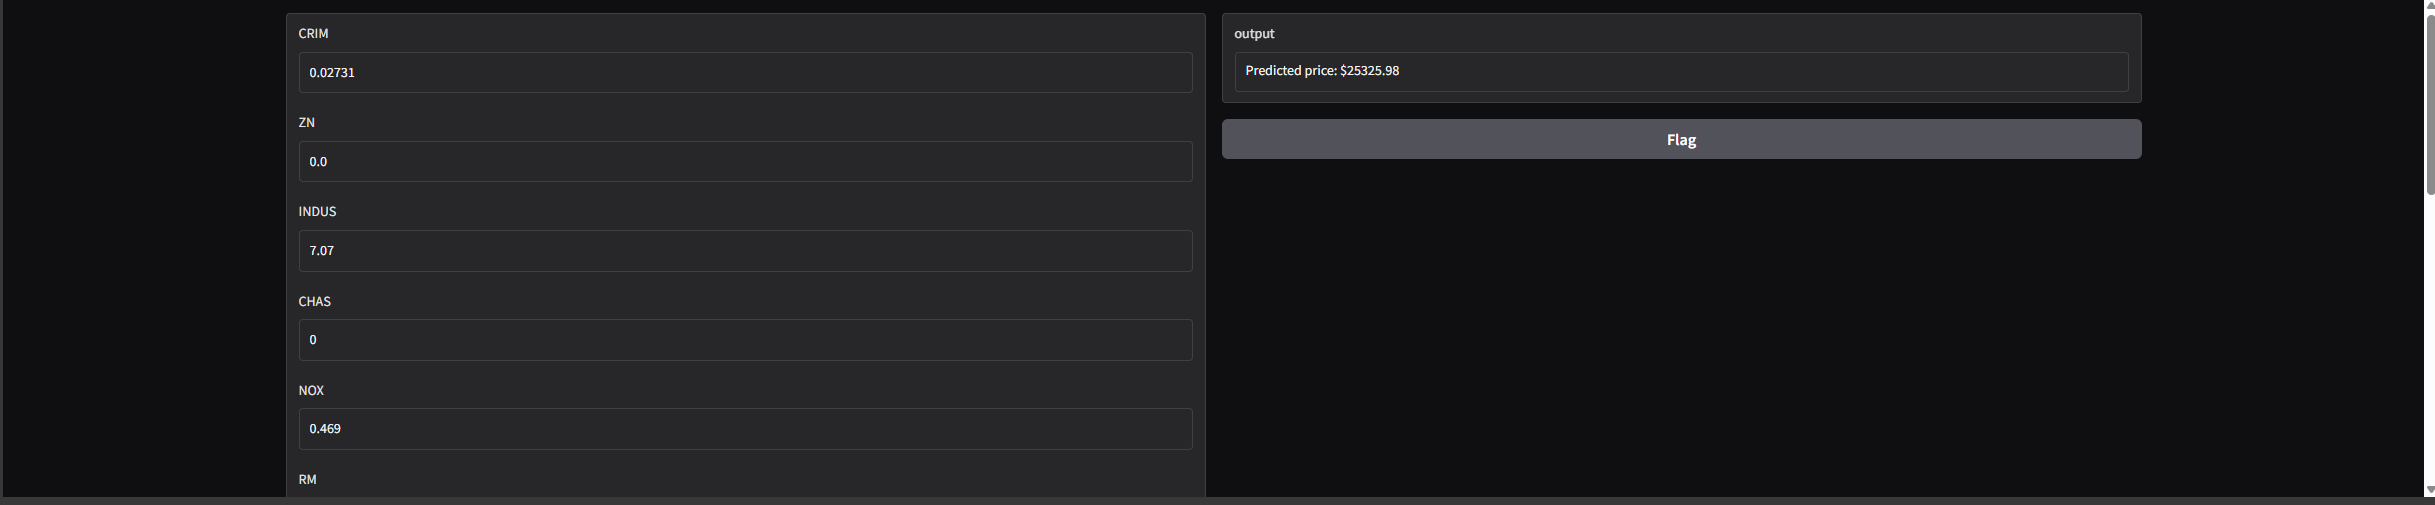

#### 2. Проверка обученной модели пользовательскими данными

In [11]:
sample_input = np.array([[0.02731, 0.0, 7.07, 0, 0.469, 6.421, 78.9, 4.9671, 2, 242, 17.8, 396.90, 9.14]])
scaled_sample = scaler.transform(sample_input)
prediction = model.predict(scaled_sample)
print(f"Predicted price: ${prediction[0][0]*1000:.2f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
Predicted price: $23537.21


## Задание №2.Обучение модели ИНС для решения задачи классификации



Порядок работы:

* 1. Собрать датасет из изображений, соответствующих не менее, чем 3 классам объектов (в
примере с пары были кошки, собаки и панды).


- 2. Для каждого класса должно быть собрано не менее 1000 изображений. Количество
изображений для каждого класса должно быть одинаковым.
Готовые датасеты можно скачать отсюда: https://www.kaggle.com/


- 3. Обучить модель глубокой нейронной сети для решения задачи классификации
изображений, по выбранным Вами классам. (В качестве примера приведён код с пары)
В конечном итоге Вы должны сохранить обученную модель для классификации
изображений, соответствующих тем классам, которые Вы выбрали, а затем воспользоваться этой моделью для предсказания классов на пользовательских изображениях.



> При выполнении заданий пробуйте использовать разные функции потерь,
методы оптимизации, функции активации и метрики ошибок.

### 1. Устанавливаем зависимости:

In [12]:
# Импортируем LabelBinarizer для преобразования текстовых меток в векторы
# (например, "кошка" -> [1, 0, 0], "собака" -> [0, 1, 0], "панда" -> [0, 0, 1])
from sklearn.preprocessing import LabelBinarizer

# Импортируем train_test_split для разделения данных на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split

# Импортируем classification_report для оценки качества классификации
from sklearn.metrics import classification_report

# Импортируем Sequential для создания последовательной модели нейронной сети
from keras.models import Sequential

# Импортируем Dense для создания плотных слоев нейронной сети
from keras.layers import Dense

# Импортируем SGD и Adam для оптимизации обучения нейронной сети
from keras.optimizers import SGD, Adam

# Импортируем paths из imutils для удобной работы с путями к изображениям
from imutils import paths

# Импортируем pyplot из matplotlib для визуализации данных
import matplotlib.pyplot as plt

# Импортируем numpy для работы с массивами данных
import numpy as np

# Импортируем random для генерации случайных чисел
import random

# Импортируем pickle для сериализации и десериализации данных
import pickle

# Импортируем cv2 для работы с изображениями
import cv2

# Импортируем os для работы с файловой системой
import os

# Импортируем cv2_imshow из google.colab.patches для отображения изображений в Colab
from google.colab.patches import cv2_imshow

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Загружаем набор данных:

In [14]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kausthubkannan/5-flower-types-classification-dataset")

print("Path to dataset files:", path)

100%|██████████| 242M/242M [00:01<00:00, 137MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kausthubkannan/5-flower-types-classification-dataset/versions/1


### 3. Указываем путь к набору данных:

In [15]:
dataset_path = "/root/.cache/kagglehub/datasets/kausthubkannan/5-flower-types-classification-dataset/versions/1/flower_images"

### 4. Загружаем набор данных и формируем общую выборку:

In [16]:
# Инициализация списков для данных и меток
data = []
labels = []

# Получаем список путей к изображениям и перемешиваем их
imagePaths = sorted(list(paths.list_images(dataset_path)))
random.seed(42)
random.shuffle(imagePaths)

# Обрабатываем каждое изображение
for imagePath in imagePaths:
    # Загружаем изображение и изменяем размер до 64x64 пикселей
    image = cv2.imread(imagePath)
    image = cv2.resize(image, (64, 64))

    # Добавляем изображение и метку в списки
    data.append(image)
    label = imagePath.split(os.path.sep)[-2]
    labels.append(label)

#### 4.1. Нормализуем данные:

Масштабируем интенсивности пикселей в диапазон [0, 1], а также преобразуем данные в массивы NumPy для повышения производительности


In [17]:
# Преобразуем данные в массивы NumPy и нормализуем
data = np.array(data, dtype="float") / 255.0
labels = np.array(labels)

# Преобразуем текстовые метки в one-hot векторы
lb = LabelBinarizer()
labels = lb.fit_transform(labels)

# Преобразуем изображения в одномерные векторы
data = data.reshape(data.shape[0], -1)

#### 4.2. Формируем обучающую и валидационную выборки:

Разделяем данные на обучающую и валидационную выборки, используя 75% данных для обучения и оставшиеся 25% для валидации

In [18]:
(trainX, testX, trainY, testY) = train_test_split(data, labels, test_size=0.25, random_state=42)

### 5. Создание модели:

#### 5.1. Определим архитектуру модели с помощью Keras:

In [19]:
model = Sequential([
    Input(shape=(64 * 64 * 3,)),
    Dense(512, activation="relu"),
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(5, activation="softmax")
])

#### 5.2. Установим значение параметров скорости обучения и общего числа эпох


In [20]:
INIT_LR = 0.001  # Начальная скорость обучения
EPOCHS = 100     # Увеличиваем количество эпох
BATCH_SIZE = 32

# Используем Adam с настройкой learning rate
opt = Adam(learning_rate=INIT_LR)

#### 5.3. Компилируем модель:

In [21]:
model.compile(
    loss="categorical_crossentropy",
    optimizer=opt,
    metrics=["accuracy"]
)

### 6. Обучение модели искусственной нейронной сети:

#### 6.1. Добавим колбэки для сохранения лучшей модели по валидационной точности и остановки обучения, в случае, если модель перестала обучаться:

In [22]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

# Колбэк для ранней остановки
earlystop = EarlyStopping(
    monitor="val_loss",  # Мониторим val_loss
    patience=10,         # Ждем 10 эпох без улучшения
    restore_best_weights=True,  # Восстанавливаем лучшие веса
    verbose=1
)

# Колбэк для сохранения лучшей модели
checkpoint = ModelCheckpoint(
    "best_model_improved.h5",
    monitor="val_accuracy",  # Сохраняем модель с лучшей val_accuracy
    save_best_only=True,
    verbose=1
)

#### 6.2. Запустим процесс обучения модели:

In [23]:
H = model.fit(
    trainX, trainY,
    validation_data=(testX, testY),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[checkpoint, earlystop],
    verbose=1
)

Epoch 1/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2884 - loss: 3.6007
Epoch 1: val_accuracy improved from -inf to 0.40160, saving model to best_model_improved.h5


118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.2888 - loss: 3.5901 - val_accuracy: 0.4016 - val_loss: 1.4514
Epoch 2/100
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4156 - loss: 1.4573
Epoch 2: val_accuracy improved from 0.40160 to 0.42240, saving model to best_model_improved.h5


118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4159 - loss: 1.4560 - val_accuracy: 0.4224 - val_loss: 1.3913
Epoch 3/100
114/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4794 - loss: 1.2882
Epoch 3: val_accuracy improved from 0.42240 to 0.43120, saving model to best_model_improved.h5


118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4798 - loss: 1.2868 - val_accuracy: 0.4312 - val_loss: 1.4484
Epoch 4/100
115/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4778 - loss: 1.2331
Epoch 4: val_accuracy improved from 0.43120 to 0.52320, saving model to best_model_improved.h5


118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4782 - loss: 1.2327 - val_accuracy: 0.5232 - val_loss: 1.2048
Epoch 5/100
105/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5277 - loss: 1.1469
Epoch 5: val_accuracy did not improve from 0.52320
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5264 - loss: 1.1502 - val_accuracy: 0.4856 - val_loss: 1.2675
Epoch 6/100
110/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5385 - loss: 1.1271
Epoch 6: val_accuracy did not improve from 0.52320
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5390 - loss: 1.1266 - val_accuracy: 0.5000 - val_loss: 1.2358
Epoch 7/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5408 - loss: 1.1306
Epoch 7: val_accuracy did not improve from 0.52320
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5409 - loss: 1.1304 - val_accuracy: 0.4456 - val_loss: 1.4442
Epoch 8/100
110/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5471 - loss: 1.1114
Epoch 8: val_accuracy improved 

...

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6754 - loss: 0.8304 - val_accuracy: 0.5824 - val_loss: 1.0987
Epoch 15/100
114/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7009 - loss: 0.7822
Epoch 15: val_accuracy did not improve from 0.58240
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7002 - loss: 0.7829 - val_accuracy: 0.5584 - val_loss: 1.2597
Epoch 16/100
104/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6992 - loss: 0.7693
Epoch 16: val_accuracy improved from 0.58240 to 0.60800, saving model to best_model_improved.h5


118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6997 - loss: 0.7687 - val_accuracy: 0.6080 - val_loss: 1.0869
Epoch 17/100
112/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7292 - loss: 0.7104
Epoch 17: val_accuracy did not improve from 0.60800
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7284 - loss: 0.7124 - val_accuracy: 0.6032 - val_loss: 1.0579
Epoch 18/100
114/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7442 - loss: 0.6710
Epoch 18: val_accuracy did not improve from 0.60800
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7438 - loss: 0.6717 - val_accuracy: 0.5416 - val_loss: 1.3675
Epoch 19/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6693 - loss: 0.8166
Epoch 19: val_accuracy did not improve from 0.60800
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6695 - loss: 0.8161 - val_accuracy: 0.5616 - val_loss: 1.2038
Epoch 20/100
112/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7372 - loss: 0.6806
Epoch 20: val_accuracy i

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7375 - loss: 0.6801 - val_accuracy: 0.6272 - val_loss: 1.0291
Epoch 21/100
110/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7582 - loss: 0.6345
Epoch 21: val_accuracy did not improve from 0.62720
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7586 - loss: 0.6329 - val_accuracy: 0.5392 - val_loss: 1.4032
Epoch 22/100
115/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7755 - loss: 0.6017
Epoch 22: val_accuracy did not improve from 0.62720
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7757 - loss: 0.6010 - val_accuracy: 0.5672 - val_loss: 1.3683
Epoch 23/100
110/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7510 - loss: 0.6274
Epoch 23: val_accuracy did not improve from 0.62720
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7525 - loss: 0.6252 - val_accuracy: 0.5616 - val_loss: 1.3267
Epoch 24/100
109/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7417 - loss: 0.6654
Epoch 24: val_accuracy 

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7430 - loss: 0.6613 - val_accuracy: 0.6400 - val_loss: 1.2027
Epoch 25/100
106/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7871 - loss: 0.5628
Epoch 25: val_accuracy did not improve from 0.64000
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7882 - loss: 0.5617 - val_accuracy: 0.5960 - val_loss: 1.4196
Epoch 26/100
111/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7935 - loss: 0.5442
Epoch 26: val_accuracy did not improve from 0.64000
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7945 - loss: 0.5412 - val_accuracy: 0.6208 - val_loss: 1.2343
Epoch 27/100
105/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8208 - loss: 0.4791
Epoch 27: val_accuracy did not improve from 0.64000
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8194 - loss: 0.4809 - val_accuracy: 0.6128 - val_loss: 1.1946
Epoch 28/100
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7801 - loss: 0.5675
Epoch 28: val_accuracy d

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7612 - loss: 0.6358 - val_accuracy: 0.6632 - val_loss: 1.2908
Epoch 30/100
103/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8013 - loss: 0.5023
Epoch 30: val_accuracy did not improve from 0.66320
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8012 - loss: 0.5020 - val_accuracy: 0.6360 - val_loss: 1.2998
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 20.


#### 6.3. Загружаем лучшую модель:

In [24]:
from keras.models import load_model

model = load_model("best_model_improved.h5")

### 7. Оценка точности:

#### 7.1. Выведем отчет классификации

In [25]:
from sklearn.metrics import classification_report

# Делаем предсказания на тестовых данных
predictions = model.predict(testX, batch_size=BATCH_SIZE)

# Выводим отчет классификации
print(classification_report(
    testY.argmax(axis=1),  # Истинные метки
    predictions.argmax(axis=1),  # Предсказанные метки
    target_names=lb.classes_  # Названия классов
))

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
              precision    recall  f1-score   support

       Lilly       0.64      0.55      0.59       223
       Lotus       0.81      0.58      0.68       256
      Orchid       0.69      0.60      0.64       265
   Sunflower       0.76      0.86      0.81       254
       Tulip       0.51      0.71      0.59       252

    accuracy                           0.66      1250
   macro avg       0.68      0.66      0.66      1250
weighted avg       0.68      0.66      0.66      1250



#### 7.2. Выведем матрицу ошибок

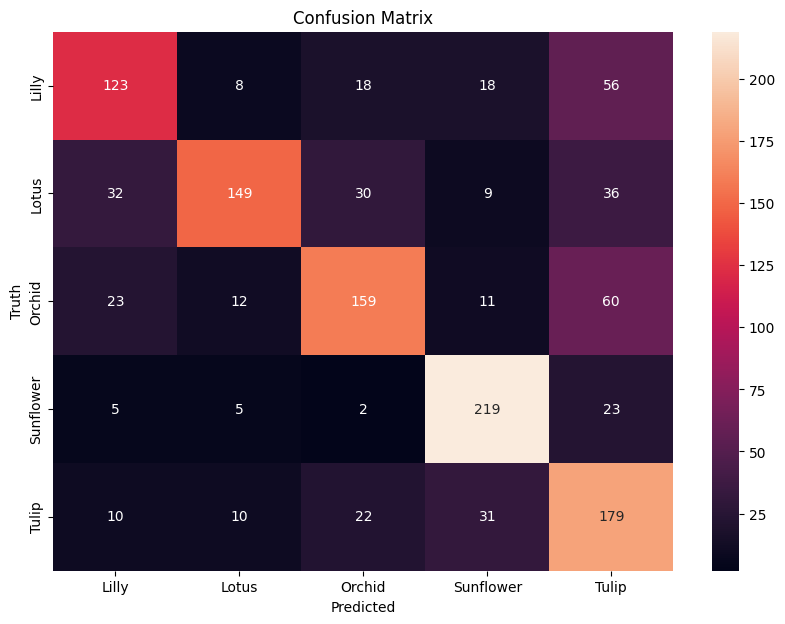

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Строим матрицу ошибок
cm = confusion_matrix(testY.argmax(axis=1), predictions.argmax(axis=1))

# Визуализируем матрицу ошибок
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=lb.classes_, yticklabels=lb.classes_)
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.title("Confusion Matrix")
plt.show()

#### 7.3. Отобразим график обучения

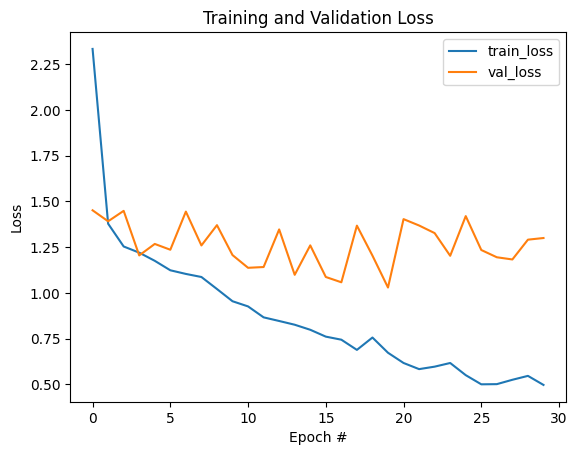

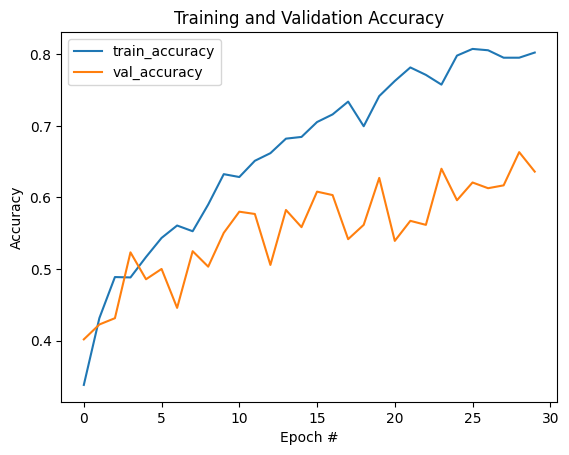

In [27]:
# График потерь (loss)
plt.figure()
plt.plot(np.arange(0, len(H.history["loss"])), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, len(H.history["val_loss"])), H.history["val_loss"], label="val_loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend()
plt.show()

# График точности (accuracy)
plt.figure()
plt.plot(np.arange(0, len(H.history["accuracy"])), H.history["accuracy"], label="train_accuracy")
plt.plot(np.arange(0, len(H.history["val_accuracy"])), H.history["val_accuracy"], label="val_accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### 8. Сохранение модели и меток классов:

In [28]:
model.save("flower_classifier.h5")

# Сохраняем LabelBinarizer (метки классов)
with open("label_bin.pickle", "wb") as f:
    pickle.dump(lb, f)

### 9. Проверка обученной модели пользовательскими данными:

#### 9.1. Импортируем необходимые библиотеки

In [29]:
!pip install gradio

In [30]:
from keras.preprocessing.image import load_img, img_to_array
import gradio as gr
from keras.models import load_model
import pickle

In [31]:
model = load_model("flower_classifier.h5")
with open("label_bin.pickle", "rb") as f:
    lb = pickle.load(f)

#### 9.2. Реализуем функцию для предобработки входных данных в той же последовательности, что и при формировании обучающей выборки:

In [32]:
def preprocess_image(image):
    # Изменяем размер и нормализуем
    image = cv2.resize(image, (64, 64))
    image = image.astype("float") / 255.0
    image = image.reshape(1, -1)  # Преобразуем в одномерный вектор
    return image

#### 9.3. Определим функцию для осуществления прогноза по загруженной модели:

In [33]:
def classify_image(image):
    # Предобрабатываем изображение
    preprocessed_image = preprocess_image(image)
    # Делаем предсказание
    proba = model.predict(preprocessed_image)[0]
    # Получаем индекс класса с наибольшей вероятностью
    idx = np.argmax(proba)
    # Получаем название класса и уверенность
    label = lb.classes_[idx]
    confidence = proba[idx]
    return f"Predicted class: {label} with confidence: {confidence:.2f}"

### 10. Визуализируем интерфейс и произведем классификацию:

Saving архидея.webp to архидея.webp


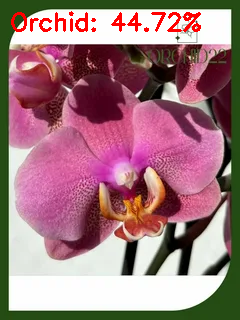


📊 Вероятности по классам:
         Lilly:  29.97%  ████████
         Lotus:  12.31%  ███
        Orchid:  44.72%  █████████████
     Sunflower:   0.23%  
         Tulip:  12.76%  ███


In [34]:
import cv2
import pickle
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow
from tensorflow.keras.models import load_model

# === ПАРАМЕТРЫ (если у тебя другие — поменяй тут) ===
IMG_SIZE = 64
MODEL_PATH = "flower_classifier.h5"
LABELBIN_PATH = "label_bin.pickle"

# 1) Загружаем пользовательское изображение
uploaded = files.upload()
filename = next(iter(uploaded.keys()))

# 2) Читаем и сохраняем копию для вывода
image = cv2.imread(filename)
if image is None:
    raise ValueError("Не удалось прочитать изображение. Попробуй загрузить .jpg/.png файл.")

output = image.copy()

# 3) Подготавливаем изображение: resize → flatten → normalize
image_processed = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
image_processed = image_processed.flatten().astype("float32") / 255.0
image_processed = image_processed.reshape((1, -1))  # (batch, features)

# 4) Загружаем модель и классы
model = load_model(MODEL_PATH)

with open(LABELBIN_PATH, "rb") as f:
    lb = pickle.load(f)

# Универсально получаем имена классов (на случай LabelBinarizer / list / np.array)
class_names = getattr(lb, "classes_", lb)
class_names = np.array(class_names)

# 5) Получаем предсказание
preds = model.predict(image_processed, verbose=0)
i = int(np.argmax(preds, axis=1)[0])

label = str(class_names[i])
confidence = float(preds[0][i]) * 100.0
text = f"{label}: {confidence:.2f}%"

# 6) Рисуем результат на изображении и показываем
cv2.putText(output, text, (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
cv2_imshow(output)

# 7) Выводим вероятности по всем классам
print("\n📊 Вероятности по классам:")
for cls, prob in zip(class_names, preds[0]):
    prob = float(prob)
    bar = "█" * int(prob * 30)
    print(f"  {str(cls):>12s}: {prob*100:6.2f}%  {bar}")

In [ ]:
# Создаем интерфейс с Gradio
interface = gr.Interface(
    fn=classify_image,  # Функция для классификации
    inputs=gr.Image(label="Upload an image"),  # Вход: изображение
    outputs=gr.Textbox(label="Prediction"),  # Выход: текст с предсказанием
    title="Flower Classification",
    description="Upload an image of a flower to classify it."
)

# Запускаем интерфейс
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://89c0565b3cf8798c36.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
